In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df_original = pd.read_csv('fra_perfumes.csv', encoding='utf-8')
df = df_original.copy()
df.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url
0,9am Afnanfor women,for women,3.73,174,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9ambyAfnanis a fragrance for women. Top notes ...,https://www.fragrantica.com/perfume/Afnan/9am-...
1,9am Dive Afnanfor women and men,for women and men,4.29,842,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am DivebyAfnanis a Aromatic Aquatic fragrance...,https://www.fragrantica.com/perfume/Afnan/9am-...
2,9am pour Femme Afnanfor women,for women,4.00,68,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour FemmebyAfnanis a Amber fragrance for ...,https://www.fragrantica.com/perfume/Afnan/9am-...
3,9pm Afnanfor men,for men,4.50,"6,865","['vanilla', 'amber', 'warm spicy', 'cinnamon',...",[],9pmbyAfnanis a Amber Vanilla fragrance for men...,https://www.fragrantica.com/perfume/Afnan/9pm-...
4,9pm pour Femme Afnanfor women,for women,3.49,63,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour FemmebyAfnanis a Amber Floral fragran...,https://www.fragrantica.com/perfume/Afnan/9pm-...


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70103 entries, 0 to 70102
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          70100 non-null  str    
 1   Gender        70100 non-null  str    
 2   Rating Value  63922 non-null  float64
 3   Rating Count  63922 non-null  str    
 4   Main Accords  70103 non-null  str    
 5   Perfumers     70103 non-null  str    
 6   Description   70100 non-null  str    
 7   url           70103 non-null  str    
dtypes: float64(1), str(7)
memory usage: 4.3 MB


In [22]:
df.isnull().sum()

Name               3
Gender             3
Rating Value    6181
Rating Count    6181
Main Accords       0
Perfumers          0
Description        3
url                0
dtype: int64

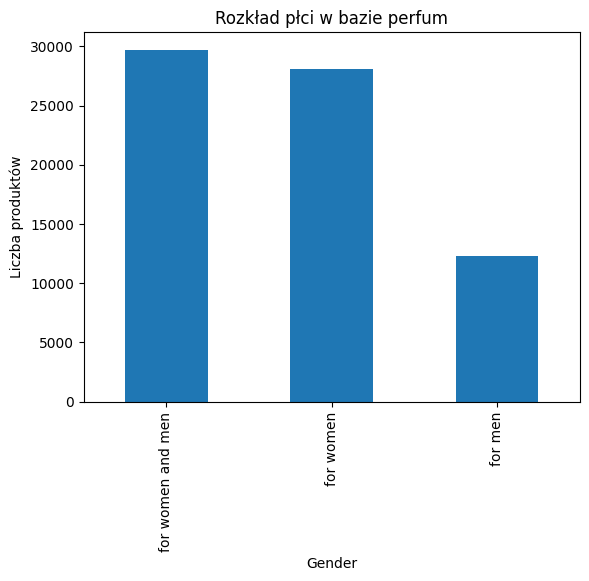

In [23]:
df['Gender'].value_counts().plot(kind='bar', title='Rozkład płci w bazie perfum')
plt.ylabel('Liczba produktów')
plt.show()

In [24]:
import pandas as pd
import re

def clean_and_prepare_data(input_file, output_file):
    df = pd.read_csv(input_file)
    
    df = df.dropna(subset=['Name', 'Description', 'Gender'])
    
    df['Rating Count'] = pd.to_numeric(
        df['Rating Count'].astype(str).str.replace(',', ''), 
        errors='coerce'
    ).fillna(0).astype(int)
    
    def extract_brand(url):
        try:
            parts = url.split('/')
            return parts[4].replace('-', ' ').title()
        except:
            return "Unknown"
    
    df['Brand'] = df['url'].apply(extract_brand)
    
    def clean_accords(accords_str):
        try:
            accords_list = eval(accords_str)
            return ' '.join(accords_list)
        except:
            return str(accords_str)
            
    df['Main_Accords_Clean'] = df['Main Accords'].apply(clean_accords)
    
    df['NLP_Search_Text'] = (
        "Nazwa: " + df['Name'].str.strip() + " | " +
        "Marka: " + df['Brand'] + " | " +
        "Płeć: " + df['Gender'] + " | " +
        "Akordy: " + df['Main_Accords_Clean'] + " | " +
        "Opis: " + df['Description']
    )
    
    df = df.drop_duplicates(subset=['url'])
    
    final_cols = [
        'Name', 'Brand', 'Gender', 'Rating Value', 'Rating Count', 
        'Main_Accords_Clean', 'Description', 'NLP_Search_Text', 'url'
    ]
    df_final = df[final_cols]
    
    df_final.to_csv(output_file, index=False)
    return df_final

cleaned_df = clean_and_prepare_data('fra_perfumes.csv', 'cleaned_perfumes_db.csv')

In [25]:
df_cleaned = pd.read_csv('cleaned_perfumes_db.csv')
df_cleaned.head()

,Name,Brand,Gender,Rating Value,Rating Count,Main_Accords_Clean,Description,NLP_Search_Text,url
0,9am Afnanfor women,Afnan,for women,3.73,174,citrus musky woody aromatic warm spicy lavende...,9ambyAfnanis a fragrance for women. Top notes ...,Nazwa: 9am Afnanfor women | Marka: Afnan | Płe...,https://www.fragrantica.com/perfume/Afnan/9am-...
1,9am Dive Afnanfor women and men,Afnan,for women and men,4.29,842,fruity woody green warm spicy aromatic citrus ...,9am DivebyAfnanis a Aromatic Aquatic fragrance...,Nazwa: 9am Dive Afnanfor women and men | Marka...,https://www.fragrantica.com/perfume/Afnan/9am-...
2,9am pour Femme Afnanfor women,Afnan,for women,4.00,68,fruity musky amber citrus powdery sweet animal...,9am pour FemmebyAfnanis a Amber fragrance for ...,Nazwa: 9am pour Femme Afnanfor women | Marka: ...,https://www.fragrantica.com/perfume/Afnan/9am-...
3,9pm Afnanfor men,Afnan,for men,4.50,6865,vanilla amber warm spicy cinnamon sweet fruity...,9pmbyAfnanis a Amber Vanilla fragrance for men...,Nazwa: 9pm Afnanfor men | Marka: Afnan | Płeć:...,https://www.fragrantica.com/perfume/Afnan/9pm-...
4,9pm pour Femme Afnanfor women,Afnan,for women,3.49,63,woody aromatic rose fruity powdery violet swee...,9pm pour FemmebyAfnanis a Amber Floral fragran...,Nazwa: 9pm pour Femme Afnanfor women | Marka: ...,https://www.fragrantica.com/perfume/Afnan/9pm-...
